In [1]:
import torch
torch.manual_seed(42)

In [2]:
x = torch.tensor([[0.1, 0.5, 0.3, 0.8, 0.2, 0.4], 
                  [0.2, 0.9, 0.3, 0.1, 0.7, 0.4]], 
                 requires_grad=True
)

In [3]:
topk_values, topk_indices = torch.topk(x, k=2, dim=1)

In [4]:
topk_values

tensor([[0.8000, 0.5000],
        [0.9000, 0.7000]], grad_fn=<TopkBackward0>)

In [5]:
topk_indices

tensor([[3, 1],
        [1, 4]])

In [6]:
torch.zeros_like(x).scatter_(1, topk_indices, 1)

tensor([[0., 1., 0., 1., 0., 0.],
        [0., 1., 0., 0., 1., 0.]])

In [7]:
mask = torch.zeros_like(x).scatter_(1, topk_indices, 1)

In [8]:
x

tensor([[0.1000, 0.5000, 0.3000, 0.8000, 0.2000, 0.4000],
        [0.2000, 0.9000, 0.3000, 0.1000, 0.7000, 0.4000]], requires_grad=True)

In [9]:
x * mask

tensor([[0.0000, 0.5000, 0.0000, 0.8000, 0.0000, 0.0000],
        [0.0000, 0.9000, 0.0000, 0.0000, 0.7000, 0.0000]],
       grad_fn=<MulBackward0>)

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from torch.nn import functional as F

# 设置随机种子和设备
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 数据加载和预处理
transform = transforms.Compose([
    # 0-1 之间
    transforms.ToTensor(),
    # 这种运行不会出错的，数据/逻辑bug，很难排查
    # transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=102400, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=12800, shuffle=False)

class KSparseAutoencoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, k=60):
        super(KSparseAutoencoder, self).__init__()
        self.k = k
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            # nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )
    
    def k_sparse(self, x):
        # 实现k-sparse约束
        topk, indices = torch.topk(x, self.k, dim=1)
        mask = torch.zeros_like(x).scatter_(1, indices, 1)
        return x * mask
    
    def forward(self, x):
        # 编码
        x = x.view(x.size(0), -1)
        encoded = self.encoder(x)
        # 应用k-sparse约束
        sparse_encoded = self.k_sparse(encoded)
        # 解码
        decoded = self.decoder(sparse_encoded)
        return decoded, sparse_encoded

def train_model(model, train_loader, num_epochs=20):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=100*1e-3)
    
    train_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        for data, _ in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            data = data.to(device)
            optimizer.zero_grad()
            
            decoded, _ = model(data)
            loss = criterion(decoded, data.view(data.size(0), -1))
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')
    
    return train_losses

def visualize_results(model, test_loader, num_images=10, k=20):
    model.eval()
    with torch.no_grad():
        data = next(iter(test_loader))[0][:num_images].to(device)
        labels = next(iter(test_loader))[1][:num_images]
        decoded, encoded = model(data)
        
        # 可视化原始图像和重构图像
        fig, axes = plt.subplots(2, num_images, figsize=(20, 4))
        
        for i in range(num_images):
            # 原始图像
            err = F.mse_loss(data[i].cpu().squeeze(), decoded[i].cpu().view(28, 28))
            print(labels[i].item(), err.item())
            axes[0, i].imshow(data[i].cpu().squeeze(), cmap='gray')
            axes[0, i].axis('off')
            axes[0, i].set_title('Original')
            
            # 重构图像
            axes[1, i].imshow(decoded[i].cpu().view(28, 28), cmap='gray')
            axes[1, i].axis('off')
        
            axes[1, i].set_title(f'Reconstructed, {err.item():.2f}')
        
        plt.tight_layout()
        # plt.show()
        plt.savefig(f'./figs/ksae-reconstructed-{k}.png')
        
        # 可视化隐层激活
        plt.figure(figsize=(10, 4))
        plt.imshow(encoded.cpu().T, aspect='auto', cmap='viridis')
        plt.colorbar()
        plt.title('Hidden Layer Activations')
        plt.xlabel('Sample')
        plt.ylabel('Hidden Unit')
        # plt.show()
        plt.savefig(f'./figs/ksae-activations-{k}.png')

def plot_training_loss(losses, k):
    plt.figure(figsize=(10, 4))
    plt.plot(losses)
    plt.title(f'Training Loss Over Time (k={k})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    # plt.show()
    plt.savefig(f'./figs/ksae-loss-{k}.png')

# 主函数
def main():
    k = 20
    model = KSparseAutoencoder(k=k).to(device)
    losses = train_model(model, train_loader)
    plot_training_loss(losses, k)
    visualize_results(model, test_loader, k=k)



Epoch 1/20: 100%|██████████| 1/1 [00:04<00:00,  5.00s/it]


Epoch [1/20], Loss: 0.231365


Epoch 2/20: 100%|██████████| 1/1 [00:04<00:00,  4.94s/it]


Epoch [2/20], Loss: 0.098132


Epoch 3/20: 100%|██████████| 1/1 [00:04<00:00,  4.92s/it]


...

Epoch [18/20], Loss: 0.076548


Epoch 19/20: 100%|██████████| 1/1 [00:04<00:00,  4.96s/it]


Epoch [19/20], Loss: 0.075487


Epoch 20/20: 100%|██████████| 1/1 [00:04<00:00,  4.95s/it]


Epoch [20/20], Loss: 0.074534
7 0.04344630613923073
2 0.10012015700340271
1 0.023380523547530174
0 0.09852606803178787
4 0.051867514848709106
1 0.01830044761300087
4 0.07633575052022934
9 0.06104143708944321
5 0.09736911952495575
9 0.07887152582406998


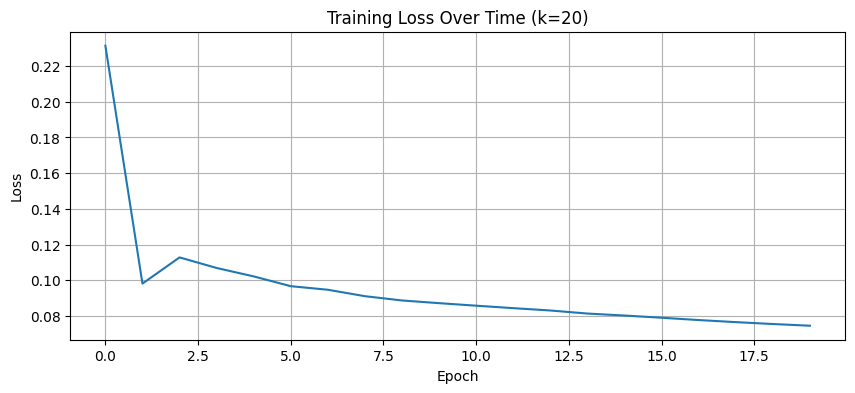

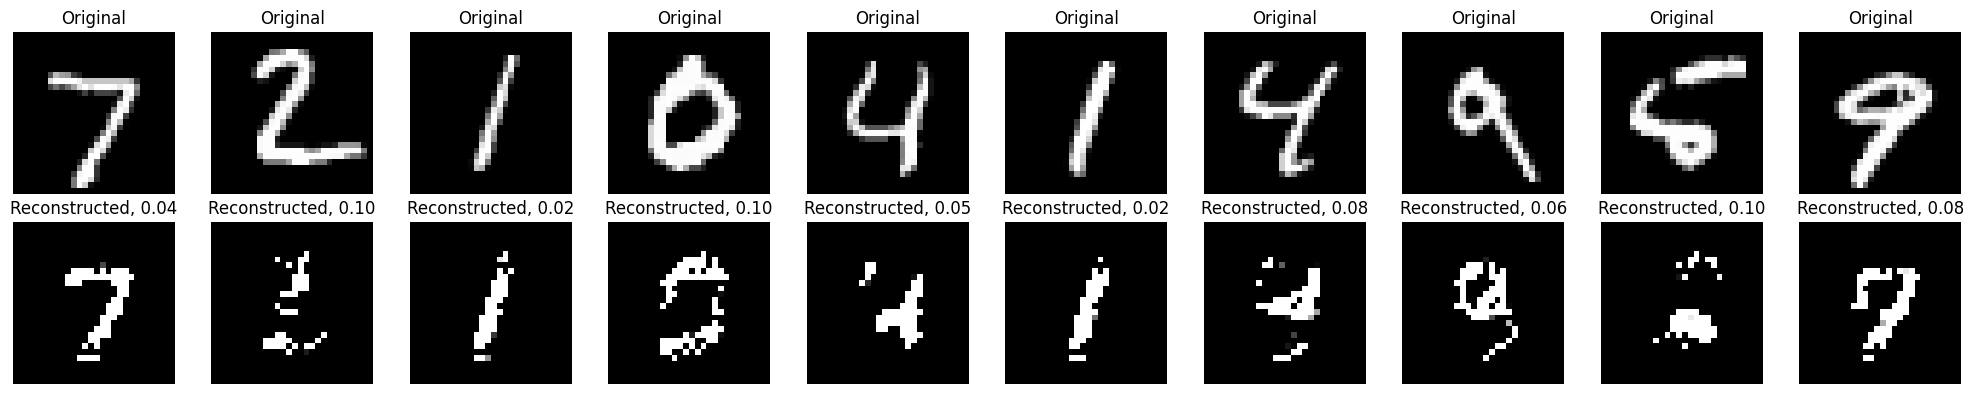

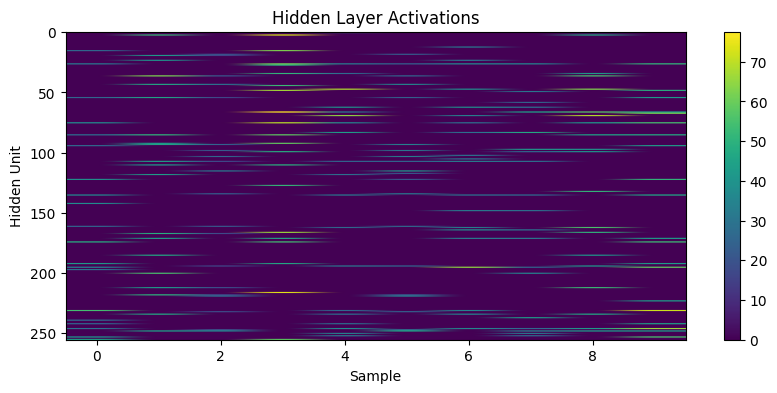

In [6]:
main()